In [1]:
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
from pathlib import Path
import json
import gzip

def read_visium_data(
    data_dir: str,
    sample_id: str,
    use_raw: bool = True
) -> anndata.AnnData:
    """
    读取10x Visium空间转录组数据
    
    Parameters
    ----------
    data_dir : str
        数据目录路径
    sample_id : str
        样本ID (如 'GSM5213483_V19S23-097_A1_S1')
    use_raw : bool
        是否使用原始数据 (filtered_feature_bc_matrix.h5)，
        如果为False则使用normalized_data.tsv.gz
    
    Returns
    -------
    anndata.AnnData
        包含空间信息的AnnData对象
    """
    data_path = Path(data_dir)
    
    # 1. 读取表达矩阵
    if use_raw:
        # 读取10x h5格式的原始数据
        h5_file = data_path / f"{sample_id}_filtered_feature_bc_matrix.h5"
        adata = sc.read_10x_h5(h5_file)
        # 使变量名唯一
        adata.var_names_make_unique()
    else:
        # 读取tsv格式的标准化数据
        tsv_file = data_path / f"{sample_id}_normalized_data.tsv.gz"
        # 读取TSV文件 (第一列是基因名，作为index)
        expr_df = pd.read_csv(tsv_file, sep='\t', index_col=0)
        # 创建AnnData (注意需要转置：行为细胞，列为基因)
        adata = anndata.AnnData(X=expr_df.T.values)
        adata.obs_names = expr_df.columns
        adata.var_names = expr_df.index
        adata.var_names_make_unique()
    
    # 2. 读取空间位置信息
    positions_file = data_path / f"{sample_id}_tissue_positions_list.csv.gz"
    
    # 读取位置文件 (无header，列名为: barcode, in_tissue, array_row, array_col, pxl_col_in_fullres, pxl_row_in_fullres)
    positions = pd.read_csv(
        positions_file,
        header=None,
        names=['barcode', 'in_tissue', 'array_row', 'array_col', 
               'pxl_col_in_fullres', 'pxl_row_in_fullres']
    )
    
    # 设置barcode为索引
    positions.set_index('barcode', inplace=True)
    
    # 3. 对齐obs和位置信息
    # 只保留在表达矩阵中存在的barcodes
    positions = positions.loc[positions.index.isin(adata.obs_names)]
    
    # 确保顺序一致
    positions = positions.reindex(adata.obs_names)
    
    # 4. 添加空间信息到obs
    adata.obs['in_tissue'] = positions['in_tissue'].values
    adata.obs['array_row'] = positions['array_row'].values
    adata.obs['array_col'] = positions['array_col'].values
    
    # 5. 设置空间坐标 (obsm)
    # 使用高分辨率图像中的像素坐标
    spatial_coords = positions[['pxl_col_in_fullres', 'pxl_row_in_fullres']].values
    adata.obsm['spatial'] = spatial_coords
    
    # 6. 尝试读取scalefactors (如果有的话)
    scalefactors_file = data_path / f"{sample_id}_scalefactors_json.json.gz"
    if scalefactors_file.exists():
        with gzip.open(scalefactors_file, 'rt') as f:
            scalefactors = json.load(f)
        adata.uns['spatial'] = {
            sample_id: {
                'scalefactors': scalefactors,
                'images': {}  # 如果有图像可以在这里添加
            }
        }
    
    # 7. 添加样本信息
    adata.obs['sample_id'] = sample_id
    
    # 8. 过滤掉不在组织上的点 (可选，根据需求)
    # adata = adata[adata.obs['in_tissue'] == 1, :]
    
    print(f"成功读取样本 {sample_id}:")
    print(f"  - 细胞数: {adata.n_obs}")
    print(f"  - 基因数: {adata.n_vars}")
    print(f"  - 组织内细胞数: {(adata.obs['in_tissue'] == 1).sum()}")
    
    return adata


def read_steady_state_data(base_dir: str = "/home_nfs/sifan.miao/1/data/DSS") -> anndata.AnnData:
    """
    读取steady state样本 (GSM5213483)
    """
    data_dir = f"{base_dir}/steady"
    sample_id = "GSM5213483_V19S23-097_A1_S1"
    return read_visium_data(data_dir, sample_id, use_raw=True)


def read_dss_data(base_dir: str = "/home_nfs/sifan.miao/1/data/DSS") -> anndata.AnnData:
    """
    读取DSS样本 (GSM5213484)
    """
    data_dir = f"{base_dir}/DSS"
    sample_id = "GSM5213484_V19S23-097_B1_S2"
    return read_visium_data(data_dir, sample_id, use_raw=True)


steady_adata = read_steady_state_data()
dss_adata = read_dss_data()

/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


成功读取样本 GSM5213483_V19S23-097_A1_S1:
  - 细胞数: 2604
  - 基因数: 31053
  - 组织内细胞数: 2604


/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


成功读取样本 GSM5213484_V19S23-097_B1_S2:
  - 细胞数: 3630
  - 基因数: 31053
  - 组织内细胞数: 3630


In [2]:

from pathlib import Path
# 建议在包根目录 `counterfactual_spatial_cvae/` 下启动 Jupyter，使 `data/` 与 `counterfactual_spatial_cvae/` 包同级可 import
NOTEBOOK_CWD = Path.cwd()

# ---------- 按需修改 ----------
CONFIG = {
    "sample_id": "151509",
    # Visium：filtered_feature_bc_matrix 所在样本目录
    "visium_root": Path("/home_nfs/sifan.miao/STcode/data/DLPFC/DLPFC_raw"),
    # layer 注释：{sample}_truth.txt
    "truth_root": Path("/home_nfs/sifan.miao/STcode/data/DLPFC/DLPFC_raw"),
    # 模拟 h5ad 输出目录（相对于当前工作目录）
    "output_dir": NOTEBOOK_CWD / "data" / "MOSTA"
}

CONFIG["output_dir"].mkdir(parents=True, exist_ok=True)
print("CWD:", NOTEBOOK_CWD)
print("Output:", CONFIG["output_dir"])

CWD: /home_nfs/sifan.miao/1/method/SpatialMETA-master/counterfactual_spatial_cvae
Output: /home_nfs/sifan.miao/1/method/SpatialMETA-master/counterfactual_spatial_cvae/data/MOSTA


In [3]:
import sys

PKG_ROOT = Path(".").resolve()
if str(PKG_ROOT) not in sys.path:
    sys.path.insert(0, str(PKG_ROOT))

from counterfactual_spatial_cvae import (
    CounterfactualSpatialCVAE,
    prepare_paired_anndata_with_slat,
    preset_fig6,
)
ad_ref, ad_qry,ad0_raw, ad1_raw = prepare_paired_anndata_with_slat(
    steady_adata,
    dss_adata,
    subsample_n_obs=2500,  # 与教程一致；不需要则设为 None
    copy=True,
)
preset = preset_fig6()
device = "cuda:1" if __import__("torch").cuda.is_available() else "cpu"
model = CounterfactualSpatialCVAE.from_adata(
    ad0_raw, ad1_raw, model_config=preset.model, device=device
)
train_cfg = preset.training
# 演示可改小 epoch；正式实验与 DLPFC.py 一致用 100
train_cfg.max_epoch = 200
train_cfg.verbose = True
history = model.fit(train_cfg)
len(history["epoch_total"]), history["epoch_total"][-1]

/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/libpyg.so: undefined symbol: _ZN3c109TupleTypeC1ESt6vectorINS_4Type24SingletonOrSharedTypePtrIS2_EESaIS4_EESt8optionalINS_13QualifiedNameEESt10shared_ptrINS_14FunctionSchemaEE
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/libpyg.so: undefined symbol: _ZN3c109TupleTypeC1ESt6vectorINS_4Type24SingletonOrSharedTypePtrIS2_EESaIS4_EESt8optionalINS_13QualifiedNameEESt10shared_ptrINS_14FunctionSchemaEE
  warnings.warn(f"An issue occurred while importing

KeyboardInterrupt: 

In [4]:
result = model.compute_drift_score(
    ad0_raw, ad1_raw,
    min_expr_logcpm=0.0,
    top_n_perturb=3000,
    n_grid=1000,
    alpha=0,
    blacklist=True,
    batch_size=1024,
)

[DriftScore] Total genes:         12240
[DriftScore] After expr+blacklist: 12107
[DriftScore] Final genes: 3000
[DriftScore] Top gene: Mptx1  score=0.9997  perturb=0.8223  spatial=0.0185  expr_log=6.646


In [5]:
result['gene'][:20]

0       Mptx1
1        Tgm3
2        Igha
3        Sycn
4     Cyp2c55
5      Jchain
6        Car1
7     Slc20a1
8      Sema4g
9        Igkc
10       Gpx2
11      Mgst3
12        Des
13      Uba52
14       Fhl1
15     Gsdmc2
16      Krt13
17       Ang4
18      Reg3b
19      Csrp1
Name: gene, dtype: object

/tmp/ipykernel_2073902/2786613108.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


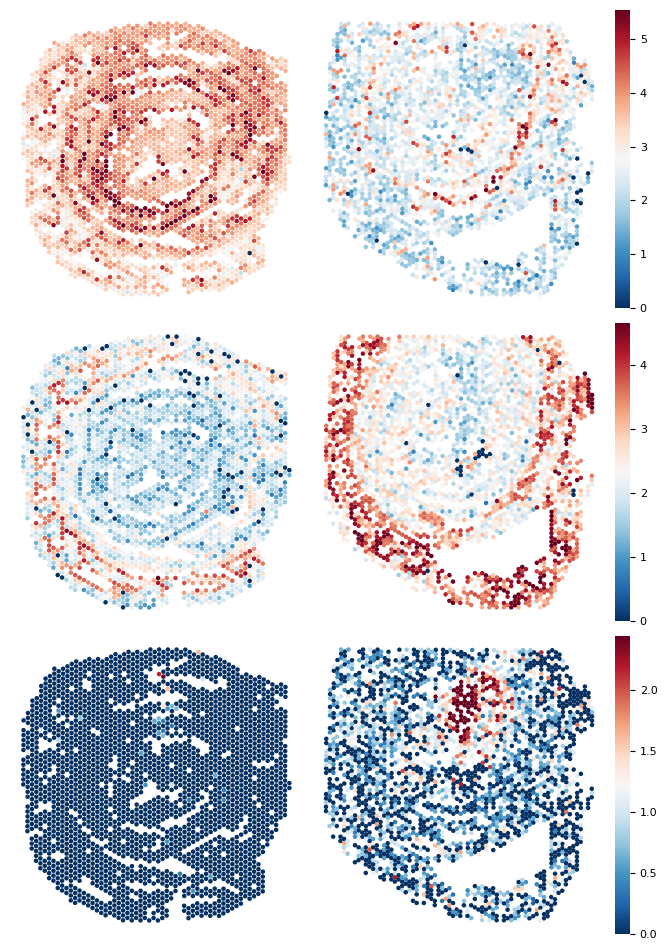

In [7]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
def center_align_spatial(adata_A, adata_B, key="spatial"):
    
    coordA = adata_A.obsm[key].copy()
    coordB = adata_B.obsm[key].copy()
    
    centerA = coordA.mean(axis=0)
    centerB = coordB.mean(axis=0)
    
    coordA_centered = coordA - centerA
    coordB_centered = coordB - centerB
    
    adata_A.obsm["spatial_center"] = coordA_centered
    adata_B.obsm["spatial_center"] = coordB_centered
    
    return adata_A, adata_B
adata_A, adata_B = center_align_spatial(ad_ref, ad_qry)
# def plot_topgene_spatial(
#     adata_A,
#     adata_B,
#     genes,
#     coord_key="spatial",
#     cmap="RdBu_r",
#     vmax_percentile=99,
#     spot_size=5
# ):

#     n = len(genes)

#     fig = plt.figure(figsize=(8, 4 * n))

#     gs = fig.add_gridspec(
#         nrows=n,
#         ncols=3,
#         width_ratios=[1, 1, 0.05],
#         wspace=0.05,
#         hspace=0.05
#     )

#     for i, g in enumerate(genes):

#         axA = fig.add_subplot(gs[i,0])
#         axB = fig.add_subplot(gs[i,1])
#         cax = fig.add_subplot(gs[i,2])

#         XA = adata_A[:, g].X
#         XB = adata_B[:, g].X

#         if sp.issparse(XA):
#             XA = XA.toarray().flatten()
#         else:
#             XA = np.array(XA).flatten()

#         if sp.issparse(XB):
#             XB = XB.toarray().flatten()
#         else:
#             XB = np.array(XB).flatten()

#         # 每个gene独立scale
#         vmax = np.percentile(np.concatenate([XA, XB]), vmax_percentile)
#         vmin = 0

#         scA = axA.scatter(
#             adata_A.obsm[coord_key][:,0],
#             adata_A.obsm[coord_key][:,1],
#             c=XA,
#             cmap=cmap,
#             s=spot_size,
#             vmin=vmin,
#             vmax=vmax
#         )

#         axB.scatter(
#             adata_B.obsm[coord_key][:,0],
#             adata_B.obsm[coord_key][:,1],
#             c=XB,
#             cmap=cmap,
#             s=spot_size,
#             vmin=vmin,
#             vmax=vmax
#         )

#         axA.set_title(f"{g} (d0)", fontsize=10)
#         axB.set_title(f"{g} (d14)", fontsize=10)

#         axA.invert_yaxis()
#         axB.invert_yaxis()

#         axA.axis("off")
#         axB.axis("off")

#         # colorbar
#         cb = fig.colorbar(scA, cax=cax)
#         cb.ax.tick_params(labelsize=8)
#         cb.outline.set_visible(False)

#     plt.tight_layout()
#     plt.savefig("/home_nfs/sifan.miao/1/result/fig/DSS/gene.png", dpi=1200)
#     plt.show()
# # genes=result[:5]['gene'].tolist()
def plot_topgene_spatial(
    adata_A,
    adata_B,
    genes,
    coord_key="spatial",
    cmap="RdBu_r",
    vmax_percentile=99,
    spot_size=5
):

    n = len(genes)

    fig = plt.figure(figsize=(8, 4 * n))

    gs = fig.add_gridspec(
        nrows=n,
        ncols=3,
        width_ratios=[1, 1, 0.05],
        wspace=0.05,
        hspace=0.05
    )

    # 存储子图对象，用于后续添加文本
    axA_list = []
    axB_list = []

    for i, g in enumerate(genes):

        axA = fig.add_subplot(gs[i, 0])
        axB = fig.add_subplot(gs[i, 1])
        cax = fig.add_subplot(gs[i, 2])

        axA_list.append(axA)
        axB_list.append(axB)

        # 提取基因表达数据
        XA = adata_A[:, g].X
        XB = adata_B[:, g].X

        if sp.issparse(XA):
            XA = XA.toarray().flatten()
        else:
            XA = np.array(XA).flatten()

        if sp.issparse(XB):
            XB = XB.toarray().flatten()
        else:
            XB = np.array(XB).flatten()

        # 每个基因独立按分位数确定颜色上限
        vmax = np.percentile(np.concatenate([XA, XB]), vmax_percentile)
        vmin = 0

        scA = axA.scatter(
            adata_A.obsm[coord_key][:, 0],
            adata_A.obsm[coord_key][:, 1],
            c=XA,
            cmap=cmap,
            s=spot_size,
            vmin=vmin,
            vmax=vmax
        )

        axB.scatter(
            adata_B.obsm[coord_key][:, 0],
            adata_B.obsm[coord_key][:, 1],
            c=XB,
            cmap=cmap,
            s=spot_size,
            vmin=vmin,
            vmax=vmax
        )

        # 隐藏坐标轴，并翻转Y轴（与原函数保持一致）
        axA.invert_yaxis()
        axB.invert_yaxis()
        axA.axis("off")
        axB.axis("off")

        # 为每行添加独立的 colorbar
        cb = fig.colorbar(scA, cax=cax)
        cb.ax.tick_params(labelsize=8)
        cb.outline.set_visible(False)

    # 让子图位置紧凑排列
    fig.tight_layout()

    # 获取第一行左子图的位置，用于顶部标注和左侧基因名的定位
    pos0_left = axA_list[0].get_position()
    pos0_right = axB_list[0].get_position()

    # 只在图片最上方标注 d0 和 d14
    # x_center_left = (pos0_left.x0 + pos0_left.x1) / 2
    # x_center_right = (pos0_right.x0 + pos0_right.x1) / 2
    # y_top = pos0_left.y1
    # fig.text(x_center_left, y_top + 0.02, "d0", ha='center', va='bottom', fontsize=10)
    # fig.text(x_center_right, y_top + 0.02, "d14", ha='center', va='bottom', fontsize=10)

    # 将基因名标注在每行的左侧
    # for ax, gene in zip(axA_list, genes):
    #     pos = ax.get_position()
    #     x_left = pos.x0 - 0.02      # 稍微左移出子图区域
    #     y_center = (pos.y0 + pos.y1) / 2
    #     fig.text(x_left, y_center, gene, ha='right', va='center', fontsize=9)

    # plt.savefig("/home_nfs/sifan.miao/1/result/fig/DSS/gene.png", dpi=1200)
    plt.show()
genes=["Igha","Cyp2c55","Krt13"]
plot_topgene_spatial(adata_A, adata_B,genes)

查询 GO Biological Process ...
  GO: 13 个显著 term
查询 KEGG ...
  KEGG: 26 个显著 term

绘图中 ...


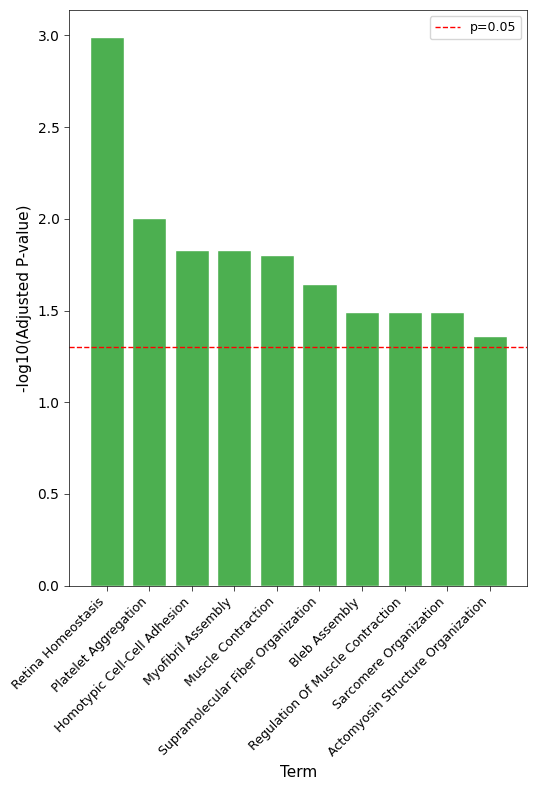

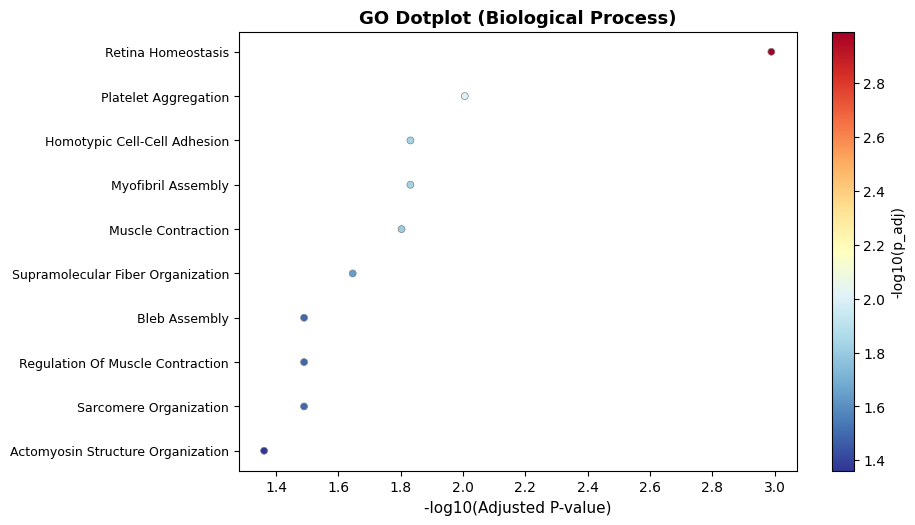

In [5]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import math
import time
# genes=list(gene_set_analy['dsep_unique'])
# genes= [gene for gene in genes if not gene.startswith('Gm')]
genes=list(result['gene'][0:100])
# genes=list(river['gene'][0:200])
genes= [gene for gene in genes if not gene.startswith('Gm')]
# genes=list(result_4['gene'][:200])
BASE = "https://maayanlab.cloud/Enrichr"

def enrichr_query(gene_list, gene_set):
    r = requests.post(f"{BASE}/addList",
                      files={"list": (None, "\n".join(gene_list)),
                             "description": (None, "query")})
    r.raise_for_status()
    user_id = r.json()["userListId"]
    time.sleep(0.5)

    r2 = requests.get(f"{BASE}/enrich",
                      params={"userListId": user_id, "backgroundType": gene_set})
    r2.raise_for_status()
    data = r2.json().get(gene_set, [])

    cols = ["Rank", "Term", "P-value", "Z-score", "Combined score",
            "Genes", "Adjusted P-value", "Old P-value", "Old Adjusted P-value"]
    return pd.DataFrame(data, columns=cols)

# ── 3. 运行富集 ───────────────────────────────────────────────
print("查询 GO Biological Process ...")
go_df = enrichr_query(genes, "GO_Biological_Process_2023")
go_df = go_df[go_df["Adjusted P-value"] < 0.05].sort_values("Adjusted P-value")
print(f"  GO: {len(go_df)} 个显著 term")

print("查询 KEGG ...")
kegg_df = enrichr_query(genes, "KEGG_2019_Mouse")
kegg_df = kegg_df[kegg_df["Adjusted P-value"] < 0.05].sort_values("Adjusted P-value")
# kegg_df.to_csv("kegg_results.csv", index=False)
print(f"  KEGG: {len(kegg_df)} 个显著 term")

# ── 4. 可视化 ─────────────────────────────────────────────────
# def barplot(df, title,  color, top_n=10):
#     if df.empty:
#         print(f"  跳过 {title}（无显著结果）"); return
#     d = df.head(top_n).copy()
#     d["label"] = d["Term"].str.replace(r"\(GO:\d+\)", "", regex=True).str.strip().str[:55]
#     d["-logP"] = -d["Adjusted P-value"].apply(lambda p: math.log10(p + 1e-300))
#     fig, ax = plt.subplots(figsize=(9, top_n * 0.42 + 1.5))
#     ax.barh(d["label"][::-1], d["-logP"][::-1], color=color, edgecolor="white")
#     ax.axvline(-math.log10(0.05), color="red", ls="--", lw=1, label="p=0.05")
#     ax.set_xlabel("-log10(Adjusted P-value)", fontsize=11)
#     ax.set_title(title, fontsize=13, fontweight="bold")
#     ax.legend(fontsize=9); plt.tight_layout()
#     plt.savefig("/home_nfs/sifan.miao/1/result/fig/DSS/Go.png", dpi=150); 
#     plt.show()
def barplot(df, title, color, top_n=10):
    if df.empty:
        print(f"  跳过 {title}（无显著结果）")
        return
    d = df.head(top_n).copy()
    d["label"] = d["Term"].str.replace(r"\(GO:\d+\)", "", regex=True).str.strip().str[:55]
    d["-logP"] = -d["Adjusted P-value"].apply(lambda p: math.log10(p + 1e-300))
    
    # 细长图形：宽<高，高度随 term 数量增加
    fig_width = 5.5
    fig_height = max(6, top_n * 0.65 + 1.5)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # 垂直条形图（最显著在左侧）
    ax.bar(d["label"], d["-logP"], color=color, edgecolor="white")
    
    # 阈值线改为水平线
    ax.axhline(-math.log10(0.05), color="red", ls="--", lw=1, label="p=0.05")
    
    # 坐标轴标签（字体与原函数 xlabel 一致）
    ax.set_xlabel("Term", fontsize=11)
    ax.set_ylabel("-log10(Adjusted P-value)", fontsize=11)
    
    # 图例字体与原函数一致
    ax.legend(fontsize=9)
    
    # 横轴标签垂直排列，避免拥挤
    # plt.xticks(rotation=60, fontsize=9)
    plt.xticks(rotation=45, ha="right", fontsize=9)
    
    # 边框改细（所有脊柱线宽0.5，刻度线宽0.5）
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(axis='both', width=0.5)
    
    plt.tight_layout()
    # plt.savefig("/home_nfs/sifan.miao/1/result/fig/DSS/Go.png", dpi=1200)
    plt.show()
def dotplot(df, title,  top_n=10):
    if df.empty:
        print(f"  跳过 {title}（无显著结果）"); return
    d = df.head(top_n).copy()
    d["label"] = d["Term"].str.replace(r"\(GO:\d+\)", "", regex=True).str.strip().str[:55]
    d["-logP"] = -d["Adjusted P-value"].apply(lambda p: math.log10(p + 1e-300))
    d["GeneCount"] = d["Genes"].apply(lambda x: len(str(x).split(";")))
    fig, ax = plt.subplots(figsize=(9, top_n * 0.42 + 1.5))
    sc = ax.scatter(d["-logP"][::-1], range(top_n),
                    s=d["GeneCount"][::-1] * 25,
                    c=d["-logP"][::-1], cmap="RdYlBu_r",
                    edgecolors="grey", linewidth=0.5)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(d["label"].values[::-1], fontsize=9)
    ax.set_xlabel("-log10(Adjusted P-value)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    plt.colorbar(sc, ax=ax, label="-log10(p_adj)")
    # plt.tight_layout(); plt.savefig(outfile, dpi=150); plt.close()
    # print(f"  保存: {outfile}")

print("\n绘图中 ...")
barplot(go_df,   "GO Enrichment (Biological Process)",    "#4CAF50")
dotplot(go_df,   "GO Dotplot (Biological Process)",  )
# barplot(kegg_df, "KEGG Enrichment (Mouse)",    "#FF5722")
# dotplot(kegg_df, "KEGG Dotplot (Mouse)" )

In [6]:
import anndata as ad
river=pd.read_csv("/home_nfs/sifan.miao/1/data/DSS/dss_river.csv")
def compute_deg_genes(adata_A, adata_B, top_n=2000):
    print("[DEG] Concatenating adata...")
    adata_combined = ad.concat(
        [adata_A, adata_B], 
        label="condition",
        keys=["E15.5", "E16.5"]
    )
    adata_combined.obs["condition"] = adata_combined.obs["condition"].astype(str)
    
    # 用 log_norm 层做 DEG
    adata_combined.X = adata_combined.layers["log_norm"]
    
    print("[DEG] Running rank_genes_groups...")
    sc.tl.rank_genes_groups(
        adata_combined,
        groupby="condition",
        method="wilcoxon",
        n_genes=top_n,
        key_added="deg"
    )
    
    deg_df = sc.get.rank_genes_groups_df(
        adata_combined, 
        group="E16.5",
        key="deg"
    ).head(top_n)
    
    deg_genes = set(deg_df["names"].tolist())
    print(f"[DEG] Found {len(deg_genes)} genes")
    return deg_genes, deg_df
deg_genes, deg_df=compute_deg_genes(ad0_raw, ad1_raw)

[DEG] Concatenating adata...
[DEG] Running rank_genes_groups...


/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[DEG] Found 2000 genes


In [8]:
deg_df

,names,scores,logfoldchanges,pvals,pvals_adj
0,Car1,35.864223,1.128375,1.103891e-281,1.501291e-278
1,Cyp2c55,34.406521,1.381734,2.014379e-259,1.896615e-256
2,Ubl5,33.342590,0.798781,9.328979e-244,8.156193e-241
3,Krt13,32.950436,5.943616,4.170121e-238,3.402818e-235
4,Ltf,31.849205,5.946237,1.350058e-222,1.032795e-219
...,...,...,...,...,...
1995,Fut2,1.551597,0.085334,1.207588e-01,1.770801e-01
1996,Pctp,1.550470,0.251724,1.210288e-01,1.773973e-01
1997,Golgb1,1.550401,0.087243,1.210452e-01,1.773973e-01
1998,Dhrs7b,1.549226,0.129946,1.213275e-01,1.777649e-01


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
def compute_classification_curve(gene_list_A, gene_list_B, gene_list_C,  # 新增第三个列表
                                  ad_ref, ad_qry, 
                                  k_values=[20, 50, 100, 200, 500, 1000, 2000],
                                  cv_folds=5,
                                  method_names=['Method A', 'Method B', 'Method C']):  # 默认三个方法名

    results = {
        'k': [],
        'score_A': [],
        'score_B': [],
        'score_C': [],  # 新增
        'std_A': [],
        'std_B': [],
        'std_C': []   # 新增
    }

    print("=" * 90)
    print("Classification Performance Curve (3 Methods Comparison)")
    print("=" * 90)
    print(f"Reference: {ad_ref.shape[0]} cells, Query: {ad_qry.shape[0]} cells")
    print(f"List A: {len(gene_list_A)} genes, List B: {len(gene_list_B)} genes, List C: {len(gene_list_C)} genes")
    print("-" * 90)

    # 调整打印格式以适应三列
    header = f"{'K':<8} {method_names[0]:<25} {method_names[1]:<25} {method_names[2]:<25}"
    subheader = f"{'':8} {'Mean ± Std':<25} {'Mean ± Std':<25} {'Mean ± Std':<25}"
    print(header)
    print(subheader)
    print("-" * 90)

    clf = LogisticRegression(max_iter=1000, random_state=42)

    for k in k_values:
        # 确保不超过三个列表的最小长度
        k_actual = min(k, len(gene_list_A), len(gene_list_B), len(gene_list_C))

        # ========== Method A ==========
        genes_A = gene_list_A[:k_actual]
        adata_A = ad.concat([ad_ref, ad_qry], label='slice_id')[:, genes_A]
        X_A = adata_A.layers["log_norm"] if "log_norm" in adata_A.layers else adata_A.X
        if hasattr(X_A, 'toarray'):
            X_A = X_A.toarray()
        y = adata_A.obs["slice_id"]

        scores_A = cross_val_score(clf, X_A, y, cv=cv_folds)
        mean_A, std_A = scores_A.mean(), scores_A.std()

        # ========== Method B ==========
        genes_B = gene_list_B[:k_actual]
        adata_B = ad.concat([ad_ref, ad_qry], label='slice_id')[:, genes_B]
        X_B = adata_B.layers["log_norm"] if "log_norm" in adata_B.layers else adata_B.X
        if hasattr(X_B, 'toarray'):
            X_B = X_B.toarray()
        # y 相同，不需要重新获取

        scores_B = cross_val_score(clf, X_B, y, cv=cv_folds)
        mean_B, std_B = scores_B.mean(), scores_B.std()

        # ========== Method C (新增) ==========
        genes_C = gene_list_C[:k_actual]
        adata_C = ad.concat([ad_ref, ad_qry], label='slice_id')[:, genes_C]
        X_C = adata_C.layers["log_norm"] if "log_norm" in adata_C.layers else adata_C.X
        if hasattr(X_C, 'toarray'):
            X_C = X_C.toarray()

        scores_C = cross_val_score(clf, X_C, y, cv=cv_folds)
        mean_C, std_C = scores_C.mean(), scores_C.std()

        # 存储结果
        results['k'].append(k_actual)
        results['score_A'].append(round(mean_A, 2))
        results['score_B'].append(round(mean_B, 2))
        results['score_C'].append(round(mean_C, 2))  # 新增
        results['std_A'].append(std_A)
        results['std_B'].append(std_B)
        results['std_C'].append(std_C)  # 新增

        # 打印三列结果
        print(f"{k_actual:<8} {mean_A:.4f} ± {std_A:.4f}        "
              f"{mean_B:.4f} ± {std_B:.4f}        "
              f"{mean_C:.4f} ± {std_C:.4f}")

        if k_actual < k:
            print(f"         (Note: max available genes = {k_actual})")

    print("=" * 90)
    return results, method_names
gene_list_A = result['gene'].tolist()         
gene_list_B = river['gene_new'].tolist() 
gene_list_C = deg_df['names'].tolist()  
results_class, names = compute_classification_curve(
    gene_list_A=gene_list_A,
    gene_list_B=gene_list_B,
    gene_list_C=gene_list_C,  # 新增
    ad_ref=ad_ref,
    ad_qry=ad_qry,
    k_values=[5,10, 50, 100, 200,500,1000],
    method_names=['RECAST', 'RIVER', 'DEG (Wilcoxon)']  # 三个自定义名称
)

Classification Performance Curve (3 Methods Comparison)
Reference: 2500 cells, Query: 2500 cells
List A: 3000 genes, List B: 17664 genes, List C: 2000 genes
------------------------------------------------------------------------------------------
K        RECAST                    RIVER                     DEG (Wilcoxon)           
         Mean ± Std                Mean ± Std                Mean ± Std               
------------------------------------------------------------------------------------------


/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


5        0.9050 ± 0.0092        0.8732 ± 0.0096        0.8896 ± 0.0078


/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


10       0.9246 ± 0.0069        0.8978 ± 0.0105        0.9288 ± 0.0023


...

200      0.9974 ± 0.0010        0.9964 ± 0.0015        0.9744 ± 0.0054


/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


500      0.9988 ± 0.0012        0.9988 ± 0.0007        0.9768 ± 0.0049


/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


1000     0.9990 ± 0.0011        0.9990 ± 0.0006        0.9812 ± 0.0049


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

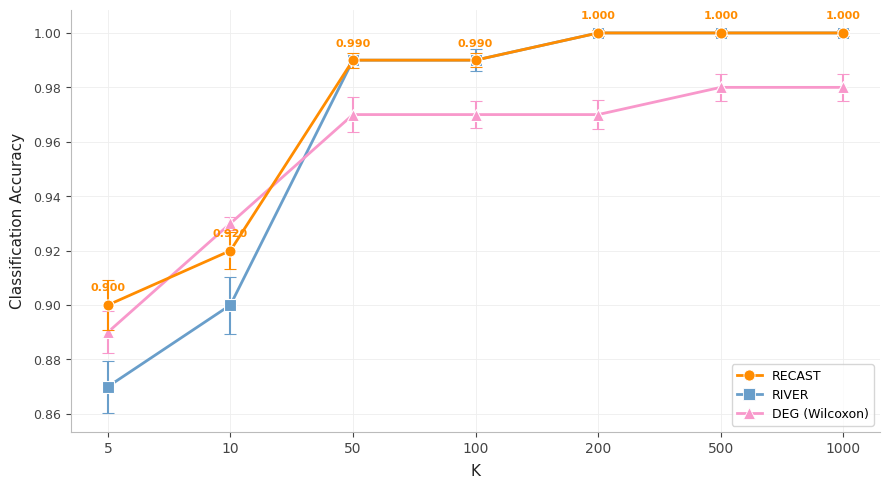

In [8]:
def plot_classification_curve_single(results, method_names, save_path=None):
    """
    绘制分类性能对比曲线 - 标准单坐标轴版本
    保留：透明度差异、橙色置顶、Times New Roman字体、简约边框风格
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import matplotlib.lines as mlines

    k_values = results['k']
    x_pos = np.arange(len(k_values))
    colors = ['#FF8C00', '#699ECA', '#F898CB'] # A:橙色, B:蓝色, C:粉色
    markers = ['o', 's', '^']
    suffixes = ['A', 'B', 'C']
    alphas = [1.0, 1.0, 1.0] # 橙色不透明，其余略微透明

    # 创建单个坐标轴
    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # 绘制曲线
    for idx, suffix in enumerate(suffixes):
        score_key = f'score_{suffix}'
        std_key = f'std_{suffix}'
        if score_key not in results: continue

        # 橙色线 (A) zorder 置顶
        current_zorder = 5 if suffix == 'A' else 3

        ax.errorbar(x_pos, results[score_key], yerr=results.get(std_key, None),
                    fmt=f'{markers[idx]}-', 
                    color=colors[idx], 
                    alpha=alphas[idx],
                    linewidth=2.0, 
                    markersize=8,
                    markerfacecolor=colors[idx], 
                    markeredgecolor='white', 
                    markeredgewidth=0.8,
                    capsize=4, 
                    elinewidth=1.5, 
                    zorder=current_zorder)

        # 仅为 Method A 显示数值标签
        if suffix == 'A':
            for i, score in enumerate(results['score_A']):
                ax.annotate(f'{score:.3f}', (i, score), textcoords="offset points",
                            xytext=(0, 10), ha='center', fontsize=8, 
                            color=colors[0], fontweight='bold', zorder=10)

    # ---------- 坐标轴与网格设置 ----------
    # 设置 X 轴
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(k) for k in k_values], fontsize=10, color='#222222')
    ax.set_xlabel('K', fontsize=11, color='#222222', labelpad=6)
    
    # 设置 Y 轴
    ax.set_ylabel('Classification Accuracy', fontsize=11, color='#222222', labelpad=6)
    ax.yaxis.set_tick_params(labelsize=9, colors='#444444')
    ax.xaxis.set_tick_params(colors='#444444')

    # 网格线样式
    ax.yaxis.grid(True, color='#EEEEEE', linewidth=0.6, zorder=0)
    for x in x_pos:
        ax.axvline(x=x, color='#EEEEEE', linewidth=0.6, linestyle='-', zorder=0)
    ax.set_axisbelow(True)

    # 边框设置
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    for sp in ['left', 'bottom']:
        ax.spines[sp].set_color('#BBBBBB')
        ax.spines[sp].set_linewidth(0.8)

    # ---------- 图例设置 ----------
    handles = []
    for idx in range(len(method_names)):
        h = mlines.Line2D([], [], 
                          color=colors[idx], 
                          marker=markers[idx], 
                          markersize=8,
                          markerfacecolor=colors[idx], 
                          markeredgecolor='white',
                          markeredgewidth=0.6,
                          linewidth=2.0,
                          linestyle='-',
                          alpha=alphas[idx],
                          label=method_names[idx])
        handles.append(h)
    legend = ax.legend(handles=handles, loc='lower right', 
                       frameon=True, facecolor='white', 
                       edgecolor='#CCCCCC', fontsize=9)
    for text in legend.get_texts():
        text.set_fontname('Times New Roman')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=1200, bbox_inches='tight', facecolor='white')
    plt.show()

# 调用
plot_classification_curve_single(results_class, names)

In [9]:
import squidpy as sq
sq.gr.spatial_neighbors(ad_ref, coord_type="generic", n_neighs=6)
sq.gr.spatial_autocorr(ad_ref, mode="moran", n_jobs=4)
sq.gr.spatial_neighbors(ad_qry, coord_type="generic", n_neighs=6)
sq.gr.spatial_autocorr(ad_qry, mode="moran", n_jobs=4)



#E15.5
sq.gr.spatial_neighbors(ad0_raw, coord_type="generic", n_neighs=6)
sq.gr.spatial_autocorr(ad0_raw, mode="moran", n_jobs=4)
sq.gr.spatial_neighbors(ad1_raw, coord_type="generic", n_neighs=6)
sq.gr.spatial_autocorr(ad1_raw, mode="moran", n_jobs=4)

/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 8038 variables were constant, will return nan for these.
  warnings.warn(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 8431 variables were constant, will return nan for these.
  warnings.warn(


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

Top-K Average Moran's I Analysis
Gene list length: 3000
Data A: 2500 cells x 31053 genes
Data B: 2500 cells x 31053 genes
------------------------------------------------------------
K        N_genes    Avg_MoranI_A    Avg_MoranI_B    Combined       
------------------------------------------------------------
5        5                 0.3715          0.4530          0.4122
10       10                0.3562          0.4145          0.3854
50       50                0.2978          0.2790          0.2884
100      100               0.2500          0.2236          0.2368
200      200               0.2060          0.1818          0.1939
300      300               0.1840          0.1584          0.1712
400      400               0.1668          0.1447          0.1557
500      500               0.1497          0.1317          0.1407
1000     1000              0.1104          0.0980          0.1042
Top-K Average Moran's I Analysis
Gene list length: 17664
Data A: 2500 cells x 31053 genes
Data

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

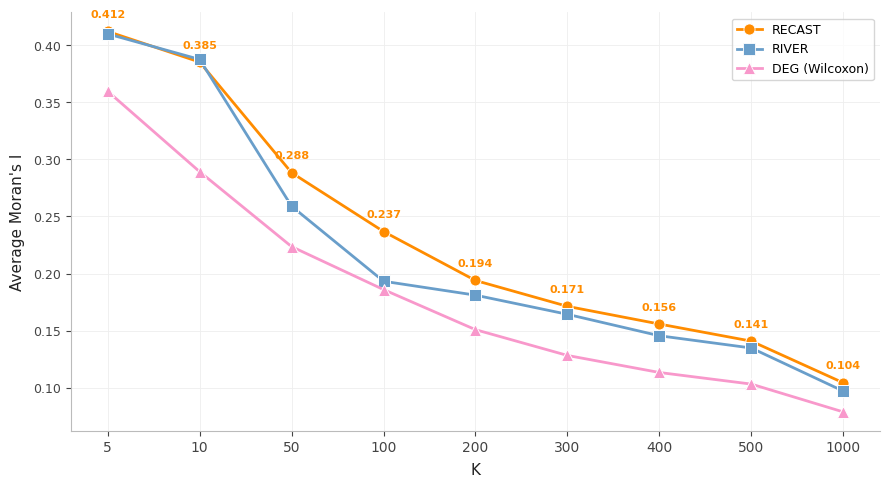

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

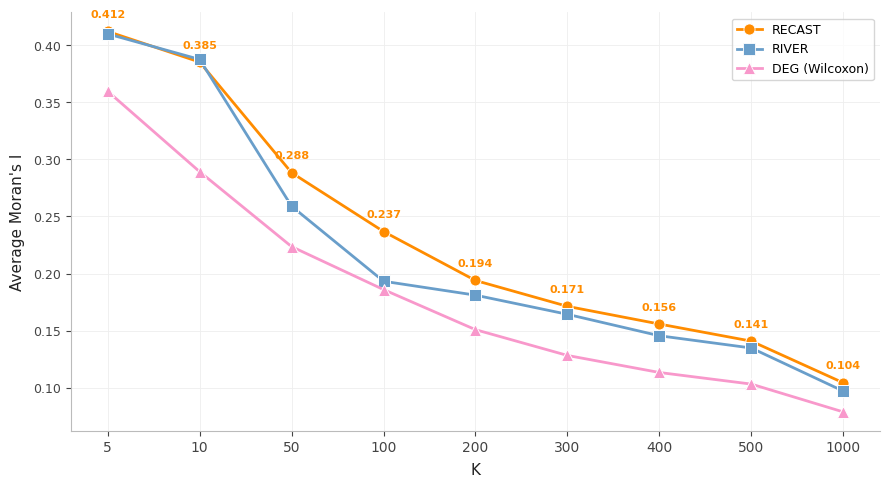

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats



def compute_topk_moranI_curve(gene_list, adata_A, adata_B, 
                               k_values=[20, 50, 100, 200, 500, 1000, 2000],
                               moran_key="moranI"):
    
    # 从uns中获取moranI DataFrame
    moran_A = adata_A.uns[moran_key].copy()
    moran_B = adata_B.uns[moran_key].copy()
    moran_B = moran_B.dropna(subset=['I'])  # 直接删除 NaN 行
    # 确保基因名是索引或列
    if 'names' in moran_A.columns:
        moran_A = moran_A.set_index('names')
    if 'names' in moran_B.columns:
        moran_B = moran_B.set_index('names')
    
    print("=" * 60)
    print("Top-K Average Moran's I Analysis")
    print("=" * 60)
    print(f"Gene list length: {len(gene_list)}")
    print(f"Data A: {adata_A.shape[0]} cells x {adata_A.shape[1]} genes")
    print(f"Data B: {adata_B.shape[0]} cells x {adata_B.shape[1]} genes")
    print("-" * 60)
    print(f"{'K':<8} {'N_genes':<10} {'Avg_MoranI_A':<15} {'Avg_MoranI_B':<15} {'Combined':<15}")
    print("-" * 60)
    
    results = {
        'k': [],
        'n_valid': [],           # 实际找到的基因数
        'avg_moran_A': [],       # 数据A的平均Moran's I
        'avg_moran_B': [],       # 数据B的平均Moran's I
        'avg_moran_combined': [], # 两个数据的平均
        'sem_A': [],             # 标准误A
        'sem_B': [],             # 标准误B
        'genes_used': []         # 实际使用的基因列表
    }
    
    for k in k_values:
        # 取Top-K基因
        topk_genes = gene_list[:min(k, len(gene_list))]
        
        # 在A中找到存在的基因
        valid_genes_A = [g for g in topk_genes if g in moran_A.index]
        moran_values_A = moran_A.loc[valid_genes_A, 'I'].values if len(valid_genes_A) > 0 else []
        
        # 在B中找到存在的基因
        valid_genes_B = [g for g in topk_genes if g in moran_B.index]
        moran_values_B = moran_B.loc[valid_genes_B, 'I'].values if len(valid_genes_B) > 0 else []
        
        # 计算统计量
        if len(moran_values_A) > 0:
            avg_A = np.mean(moran_values_A)
            sem_A = stats.sem(moran_values_A) if len(moran_values_A) > 1 else 0
        else:
            avg_A = np.nan
            sem_A = np.nan
            
        if len(moran_values_B) > 0:
            avg_B = np.mean(moran_values_B)
            sem_B = stats.sem(moran_values_B) if len(moran_values_B) > 1 else 0
        else:
            avg_B = np.nan
            sem_B = np.nan
        
        # 合并两个数据的Moran's I（取平均）
        if not np.isnan(avg_A) and not np.isnan(avg_B):
            combined = (avg_A + avg_B) / 2
        elif not np.isnan(avg_A):
            combined = avg_A
        elif not np.isnan(avg_B):
            combined = avg_B
        else:
            combined = np.nan
        
        n_valid = min(len(valid_genes_A), len(valid_genes_B))
        
        results['k'].append(k)
        results['n_valid'].append(n_valid)
        results['avg_moran_A'].append(avg_A)
        results['avg_moran_B'].append(avg_B)
        results['avg_moran_combined'].append(combined)
        results['sem_A'].append(sem_A)
        results['sem_B'].append(sem_B)
        results['genes_used'].append(list(set(valid_genes_A) & set(valid_genes_B)))
        
        print(f"{k:<8} {n_valid:<10} {avg_A:>13.4f}   {avg_B:>13.4f}   {combined:>13.4f}")
        
        if len(valid_genes_A) < k or len(valid_genes_B) < k:
            print(f"         (Warning: A={len(valid_genes_A)}, B={len(valid_genes_B)} genes found)")
    
    print("=" * 60)
    return results

def compare_multiple_gene_lists(gene_lists_dict, adata_A, adata_B, k_values=[100, 500, 1000],save_path=None):
    """
    比较多个基因列表 - 参考风格版本
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import matplotlib.lines as mlines
    
    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # 生成均匀分布的x位置
    x_pos = np.arange(len(k_values))
    
    # 颜色方案
    colors = [
        '#FF8C00',  # 橙色 - Method A
        '#699ECA',  # 蓝色 - Method B
        '#F898CB'   # 粉色 - Method C (新增)
    ]
    
    # 标记样式
    markers = ['o', 's', '^']  # 圆形、方形、三角形
    
    # 绘制曲线
    method_names = list(gene_lists_dict.keys())
    for idx, (name, gene_list) in enumerate(gene_lists_dict.items()):
        results = compute_topk_moranI_curve(gene_list, adata_A, adata_B, k_values)
        values = results['avg_moran_combined']
        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]
        
        ax.plot(x_pos, values,
                color=color,
                linewidth=2.0,
                linestyle='-',
                alpha=1.0,
                marker=marker,
                markersize=8,
                markerfacecolor=color,
                markeredgecolor='white',
                markeredgewidth=0.7,
                zorder=3,
                label=name)
        
        # 显示数值标签
        if idx==0:
            offset_y = 10
            for i, (x, score) in enumerate(zip(x_pos, values)):
                ax.annotate(f'{score:.3f}', (x, score), textcoords="offset points",
                            xytext=(0, offset_y), ha='center', fontsize=8, 
                            color=color, fontweight='bold')
    
    # ---------- 坐标轴设置 ----------
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(k) for k in k_values], fontsize=10, color='#222222')
    # ax.set_xticklabels([f'K={k}' for k in k_values], fontsize=10, color='#222222')
    ax.set_xlabel('K', fontsize=11, color='#222222', labelpad=6)
    ax.set_ylabel("Average Moran's I", fontsize=11, color='#222222', labelpad=6)
    ax.yaxis.set_tick_params(labelsize=9, colors='#444444')
    ax.xaxis.set_tick_params(colors='#444444')
    
    # 网格线
    ax.yaxis.grid(True, color='#EEEEEE', linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    
    # 垂直分割线
    for x in x_pos:
        ax.axvline(x=x, color='#EEEEEE', linewidth=0.6, linestyle='-', zorder=0)
    
    # 边框设置
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    for sp in ['left', 'bottom']:
        ax.spines[sp].set_color('#BBBBBB')
        ax.spines[sp].set_linewidth(0.8)
    
    # # 保持原范围不变
    # ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    
    # ---------- 图例 ----------
    handles = []
    for idx, name in enumerate(method_names):
        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]
        h = mlines.Line2D([], [],
                          color=color,
                          linewidth=2.0,
                          linestyle='-',
                          alpha=1.0,
                          marker=marker,
                          markersize=8,
                          markerfacecolor=color,
                          markeredgecolor='white',
                          markeredgewidth=0.6,
                          label=name)
        handles.append(h)
    
    legend = ax.legend(handles=handles, loc='upper right', frameon=True, 
                       facecolor='white', edgecolor='#CCCCCC', fontsize=9)
    for text in legend.get_texts():
        text.set_fontname('Times New Roman')
    
    # # 标题
    # ax.set_title("Comparison of Different Gene Selection Methods", fontsize=12, 
    #              color='#222222', fontweight='bold', pad=10)
    if save_path:
        plt.savefig(save_path, dpi=1200, bbox_inches='tight', facecolor='white')
        print(f"\nFigure saved to: {save_path}")
    
    plt.tight_layout()
    plt.show()
    return fig


# ==================== 使用示例 ====================

# 运行分析
k_values = [5, 10, 50, 100, 200, 300,400,500, 1000]
list_A = result['gene'].tolist() 
list_B=river['gene_new'].tolist()
list_C= deg_df['names'].tolist()  
gene_lists_dict={"RECAST":list_A,"RIVER":list_B,"DEG (Wilcoxon)":list_C}

compare_multiple_gene_lists(gene_lists_dict, ad_qry, ad_ref,k_values)

contrib matrix shape: (4338, 20)
columns: ['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5'] ...
CREST: 200 top genes, 166 found in contrib matrix
RIVER: 196 top genes, 121 found in contrib matrix
Wilcoxon: 200 top genes, 47 found in contrib matrix

Factors significant in at least one method: 17
['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5', 'factor_8', 'factor_10', 'factor_11', 'factor_12', 'factor_13', 'factor_14', 'factor_16', 'factor_17', 'factor_18', 'factor_19', 'factor_6', 'factor_20']

Figure saved: /home_nfs/sifan.miao/1/data/DSS/output/nmf_enrichment_heatmap.pdf
Results saved: /home_nfs/sifan.miao/1/data/DSS/output/nmf_enrichment_results.csv

=== Significant enrichments ===
method    factor  overlap  odds_ratio        p_adj
 CREST  factor_3       29   33.247842 4.086839e-25
 CREST  factor_4       22   18.142055 1.095837e-15
 CREST factor_18       21   16.622809 1.278809e-14
 CREST  factor_1       19   13.907147 2.270026e-12
 CREST  factor_2       16   

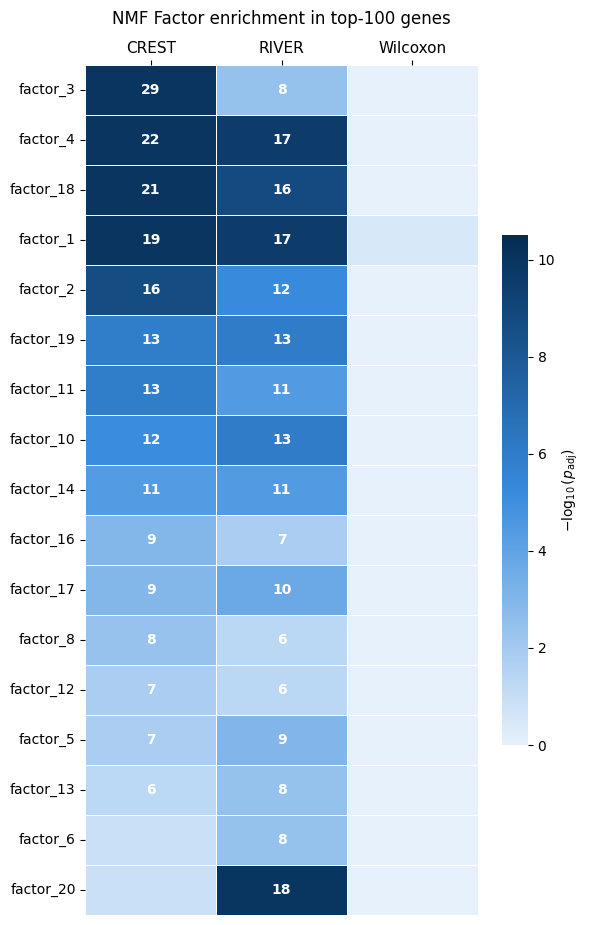

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
 
# ============================================================
# 0. 路径配置 — 修改为你的实际路径
# ============================================================
DATA_DIR        = Path("/home_nfs/sifan.miao/1/data/DSS/")
CONTRIB_PATH    = DATA_DIR / "/home_nfs/sifan.miao/1/data/DSS/contrib_matrix.csv"
CREST_PATH      = DATA_DIR / "ours.csv"
RIVER_PATH      = DATA_DIR / "dss_river.csv"
WILCOXON_PATH   = DATA_DIR / "deg_df.csv"
OUT_DIR         = DATA_DIR / "output"
OUT_DIR.mkdir(exist_ok=True)
 
TOP_K               = 200   # 每个方法取前K个基因
N_TOP_PER_FACTOR    = 50   # 每个Factor取权重前N的基因作为基因集
PADJ_THRESHOLD      = 0.05  # 显著性阈值
 
# ============================================================
# 1. 读取NMF权重矩阵
# ============================================================
contrib = pd.read_csv(CONTRIB_PATH, index_col=0)
print(f"contrib matrix shape: {contrib.shape}")   # 期望 4338 x 20
print(f"columns: {contrib.columns.tolist()[:5]} ...")
 
all_genes = set(contrib.index)
n_background = len(all_genes)
 
# 每个Factor取权重最高的前N个基因
factor_gene_sets = {}
for col in contrib.columns:
    top_genes = contrib[col].nlargest(N_TOP_PER_FACTOR).index.tolist()
    factor_gene_sets[col] = set(top_genes)
 
# ============================================================
# 2. 读取各方法基因排名
# ============================================================
def load_top_genes(path, k=TOP_K, gene_col="gene"):
    df = pd.read_csv(path)
    if gene_col not in df.columns:
        raise ValueError(f"Column '{gene_col}' not found. Available: {df.columns.tolist()}")
    return set(df[gene_col].iloc[:k].tolist())
k=TOP_K
method_genes = {
    "CREST"    : set(result['gene'].iloc[:k].tolist()),
    "RIVER"    : set(river['gene_new'].iloc[:k].tolist()),
    "Wilcoxon" : set(list(deg_genes)[:k]),
}
 
# 验证基因名是否在背景集中
for method, genes in method_genes.items():
    overlap = genes & all_genes
    print(f"{method}: {len(genes)} top genes, {len(overlap)} found in contrib matrix")
 
# ============================================================
# 3. Fisher精确检验
# ============================================================
def run_fisher(method_top: set, factor_genes: set, background: set):
    """
    2x2列联表:
                  In Factor    Not in Factor
    In top-K         a              b
    Not in top-K     c              d
    """
    a = len(method_top & factor_genes)
    b = len(method_top) - a
    c = len(factor_genes - method_top)          # 在factor不在top
    d = n_background - a - b - c
    d = max(d, 0)                               # 防止负数
 
    table = [[a, b], [c, d]]
    _, p = fisher_exact(table, alternative="greater")
 
    # Odds Ratio 手动计算（避免除零）
    or_val = (a * d) / (b * c) if (b > 0 and c > 0) else np.inf
 
    return {"overlap": a, "odds_ratio": or_val, "p_value": p}
 
records = []
for method, top_genes in method_genes.items():
    for factor, factor_genes in factor_gene_sets.items():
        res = run_fisher(top_genes, factor_genes, all_genes)
        records.append({
            "method": method,
            "factor": factor,
            **res
        })
 
results = pd.DataFrame(records)
 
# BH多重检验校正（在所有检验上统一校正）
_, p_adj, _, _ = multipletests(results["p_value"], method="fdr_bh")
results["p_adj"]   = p_adj
results["log10p"]  = -np.log10(results["p_adj"] + 1e-10)
results["significant"] = results["p_adj"] < PADJ_THRESHOLD
 
# ============================================================
# 4. 筛选：只保留至少一个方法显著的Factor
# ============================================================
sig_factors = (
    results[results["significant"]]
    ["factor"]
    .unique()
    .tolist()
)
print(f"\nFactors significant in at least one method: {len(sig_factors)}")
print(sig_factors)
 

CREST top100: 90 genes found in contrib matrix

显著富集的Factor数: 14
   factor                                          label  overlap  odds_ratio        p_adj
factor_13          F13 Goblet cell / proximal epithelium        6    3.156535 2.413496e-02
factor_10            F10 Distal damaged epithelium (d14)        8    4.407211 1.509596e-03
factor_14      F14 Severe damage / stress response (d14)        8    4.407211 1.509596e-03
 factor_8            F8  Ribosomal / translation program       11    6.506756 9.367584e-06
factor_19             F19 Proximal healing program (d14)       12    7.272727 1.429016e-06
factor_20 F20 Proliferating crypts / organogenesis (d14)       12    7.272727 1.429016e-06
 factor_2                               F2  Muscle layer       13    8.074787 2.237091e-07
factor_11          F11 Proximal epithelium healing (d14)       13    8.074787 2.237091e-07
factor_16                        F16 ILF / stromal mixed       13    8.074787 2.237091e-07
 factor_1        F1  Prox

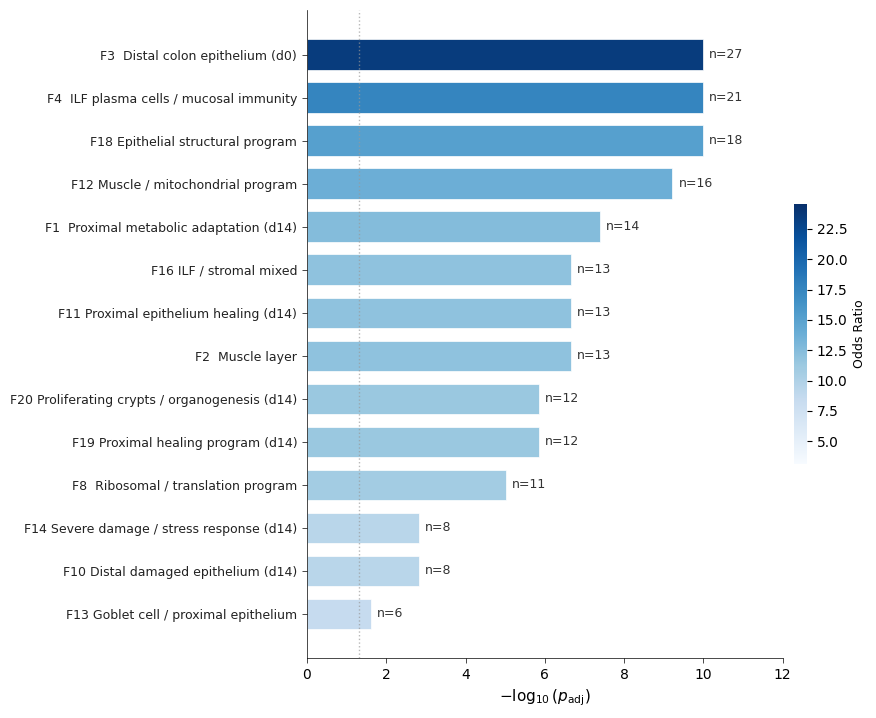

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# ============================================================
# Factor生物学注释与分组
# ============================================================
factor_labels = {
    "factor_1":  "F1  Proximal metabolic adaptation (d14)",
    "factor_2":  "F2  Muscle layer",
    "factor_3":  "F3  Distal colon epithelium (d0)",
    "factor_4":  "F4  ILF plasma cells / mucosal immunity",
    "factor_5":  "F5  ECM remodeling / edema (d14)",
    "factor_6":  "F6  Muscle / neural background",
    "factor_7":  "F7  Squamous metaplasia (d14)",
    "factor_8":  "F8  Ribosomal / translation program",
    "factor_9":  "F9  ILF structure / lymphoid follicle",
    "factor_10": "F10 Distal damaged epithelium (d14)",
    "factor_11": "F11 Proximal epithelium healing (d14)",
    "factor_12": "F12 Muscle / mitochondrial program",
    "factor_13": "F13 Goblet cell / proximal epithelium",
    "factor_14": "F14 Severe damage / stress response (d14)",
    "factor_15": "F15 Enteric nervous system (ENS)",
    "factor_16": "F16 ILF / stromal mixed",
    "factor_17": "F17 Submucosal stroma, TGFβ/Wnt (d14)",
    "factor_18": "F18 Epithelial structural program",
    "factor_19": "F19 Proximal healing program (d14)",
    "factor_20": "F20 Proliferating crypts / organogenesis (d14)",
}

d14_factors = {
    "factor_1", "factor_5", "factor_7", "factor_10",
    "factor_11", "factor_14", "factor_17", "factor_19", "factor_20"
}
d0_factors = {
    "factor_2", "factor_3", "factor_4", "factor_6",
    "factor_9", "factor_12", "factor_13", "factor_15",
    "factor_16", "factor_18"
}

def get_bar_color(factor_name, alpha=0.85):
    if factor_name in d14_factors:
        return "#D85A30"
    elif factor_name in d0_factors:
        return "#3266AD"
    else:
        return "#B4B2A9"

# ============================================================
# Fisher检验（只跑CREST）
# ============================================================
N_TOP_PER_FACTOR = 100
TOP_K = 100
PADJ_THRESHOLD = 0.05

all_genes = set(contrib.index)
n_background = len(all_genes)

factor_gene_sets = {}
for col in contrib.columns:
    top_genes = contrib[col].nlargest(N_TOP_PER_FACTOR).index.tolist()
    factor_gene_sets[col] = set(top_genes)

# 只保留CREST
crest_top = set(result['gene'].iloc[:TOP_K].tolist())
crest_in_bg = crest_top & all_genes
print(f"CREST top{TOP_K}: {len(crest_in_bg)} genes found in contrib matrix")

def run_fisher(method_top, factor_genes, n_bg):
    a = len(method_top & factor_genes)
    b = len(method_top) - a
    c = len(factor_genes - method_top)
    d = max(n_bg - a - b - c, 0)
    _, p = fisher_exact([[a, b], [c, d]], alternative="greater")
    or_val = (a * d) / (b * c) if (b > 0 and c > 0) else np.inf
    return {"overlap": a, "odds_ratio": or_val, "p_value": p}

records = []
for factor, factor_genes in factor_gene_sets.items():
    res = run_fisher(crest_in_bg, factor_genes, n_background)
    records.append({"factor": factor, **res})

df = pd.DataFrame(records)
_, df["p_adj"], _, _ = multipletests(df["p_value"], method="fdr_bh")
df["log10p"]      = -np.log10(df["p_adj"] + 1e-10)
df["significant"] = df["p_adj"] < PADJ_THRESHOLD
df["label"]       = df["factor"].map(factor_labels)
df["color"]       = df["factor"].apply(get_bar_color)

# 只保留显著的Factor，按log10p降序
df_sig = (df[df["significant"]]
          .sort_values("log10p", ascending=True)  # 升序→barh从下到上递增
          .reset_index(drop=True))

print(f"\n显著富集的Factor数: {len(df_sig)}")
print(df_sig[["factor", "label", "overlap", 
              "odds_ratio", "p_adj"]].to_string(index=False))


fig, ax = plt.subplots(figsize=(9, max(4, len(df_sig) * 0.52)))

# 用单一颜色系，按OR值深浅编码
norm = mcolors.Normalize(
    vmin=df_sig["odds_ratio"].min(),
    vmax=df_sig["odds_ratio"].max()
)
cmap_bar = plt.cm.Blues
bar_colors = [cmap_bar(norm(v) * 0.7 + 0.25) 
              for v in df_sig["odds_ratio"]]

bars = ax.barh(
    y=range(len(df_sig)),
    width=df_sig["log10p"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.5,
    height=0.7,
)

# colorbar显示OR值
sm = plt.cm.ScalarMappable(cmap=cmap_bar, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.02)
cbar.set_label("Odds Ratio", fontsize=9)
cbar.outline.set_visible(False)

# bar右侧标注overlap数
x_max = df_sig["log10p"].max()
for i, row in df_sig.iterrows():
    ax.text(
        row["log10p"] + x_max * 0.015,
        i,
        f'n={int(row["overlap"])}',
        va="center",
        ha="left",
        fontsize=9,
        color="#333333"
    )

# y轴标签：去掉颜色区分，统一深灰
ax.set_yticks(range(len(df_sig)))
ax.set_yticklabels(df_sig["label"], fontsize=9, color="#222222")

# 显著性阈值竖线
threshold_line = -np.log10(PADJ_THRESHOLD)
ax.axvline(
    x=threshold_line,
    color="#999999", linestyle=":",
    linewidth=1, alpha=0.7
)

# 轴设置
ax.set_xlabel(r"$-\log_{10}(p_\mathrm{adj})$", fontsize=11)
ax.set_xlim(0, x_max * 1.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ---------- 使横轴和纵轴更细 ----------
# 设置底部和左侧轴线宽度
ax.spines["bottom"].set_linewidth(0.5)
ax.spines["left"].set_linewidth(0.5)
# 设置刻度线宽度
ax.tick_params(axis='both', width=0.5)
plt.tight_layout()
plt.savefig("nmf_enrichment_crest_only.pdf",
            bbox_inches="tight", dpi=1200)
plt.savefig("nmf_enrichment_crest_only.png",
            bbox_inches="tight", dpi=1200)
plt.show()